In [1]:
import pandas as pd
import numpy as np

from app import BacktestDCA
from ploter import ploter

from loader import loader
import configs.strategy as strategy

/Users/aleksejkitajskij/Desktop/DCA/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
crypto_dfs = loader(strategy.CRYPTO)
close = crypto_dfs["Close"]
close.to_csv("data/crypto.csv")

stock_dfs = loader(strategy.STOCKS)
close = stock_dfs["Close"]
close.to_csv("data/stocks.csv")

Loading data for BTC from 2026-02-13 to 2026-09-24...


[*********************100%***********************]  1 of 1 completed


Loading data for ETH from 2026-02-13 to 2026-09-24...


[*********************100%***********************]  1 of 1 completed


Loading data for BNB from 2026-02-13 to 2026-09-24...


...

[*********************100%***********************]  1 of 1 completed


Loading data for AVAX from 2026-02-13 to 2026-09-24...


[*********************100%***********************]  1 of 1 completed


Loading data for SPY from 2026-02-13 to 2026-09-24...


[*********************100%***********************]  1 of 1 completed


In [3]:
df_crypto = pd.read_csv("data/crypto.csv", index_col=0, parse_dates=True)
crypto_strategy={'buy_amount': strategy.crypto_buy_amount, 'freq': strategy.crypto_freq}

df_crypto

,BTC,ETH,BNB,XRP,SOL,DOT,ADA,LINK,AVAX
Date,,,,,,,,,
2026-02-13,68857.843750,2048.527344,619.083862,1.407463,84.322540,1.329377,0.272692,8.768282,9.146927
2026-02-14,69767.625000,2086.009766,633.345215,1.509980,88.160835,1.421081,0.295266,9.088452,9.587682
2026-02-15,68788.187500,1966.042969,614.638000,1.474857,86.005096,1.356787,0.281780,8.781871,9.285936
2026-02-16,68843.156250,1997.917725,626.570679,1.486678,86.428787,1.375550,0.285491,8.925537,9.259410
2026-02-17,67494.218750,1992.194336,617.562073,1.474404,85.197609,1.346494,0.280967,8.830567,9.138813
...,...,...,...,...,...,...,...,...,...
2026-09-19,81233.679688,2631.962646,762.044373,1.410446,111.014938,1.123093,0.227764,12.428622,10.086184
2026-09-20,81142.609375,2642.997559,772.348145,1.409852,111.132912,1.134866,0.227967,12.512976,11.337066
2026-09-21,86602.914062,2776.468262,798.890137,1.533043,118.750130,1.206280,0.244812,13.134330,11.227929


In [4]:
df_stocks = pd.read_csv("data/stocks.csv", index_col=0, parse_dates=True)
stocks_strategy={'buy_amount': strategy.stock_buy_amount, 'freq': strategy.stock_freq}

df_stocks

,SPY
Date,
2026-02-13,681.750000
2026-02-17,682.849976
2026-02-18,686.289978
2026-02-19,684.479980
2026-02-20,689.429993
...,...
2026-09-17,762.599976
2026-09-18,761.690002
2026-09-21,773.500000


In [5]:
def visualaise_strategy(df, strategy):

    total_invested = 0
    total_profit = 0
    total_return = 0
    total_value = 0

    for stock in df.columns:
        stock_prices = df[stock]

        try:
            bt = BacktestDCA(
            target=stock,
            prices=stock_prices,
            strategy=strategy
            )
            result, metrics = bt.run()
            ploter(metrics=metrics, history=result)
        except Exception as e:
            print(f"Error backtesting {stock}: {e}")
            continue

        total_invested += metrics['Cash_spent']
        total_profit += metrics['Profit']
        total_return += metrics['Cash_return']
        total_value += metrics['Portfolio'] + metrics['Cash_return']

    print(f"Total invested: ${total_invested:.2f}")
    print(f"Total profit: ${total_profit:.2f}")
    print(f"Total return: ${total_return:.2f}")
    print(f"Total value: ${total_value:.2f}")

12:50:43 - cmdstanpy - INFO - Chain [1] start processing
12:50:43 - cmdstanpy - INFO - Chain [1] done processing


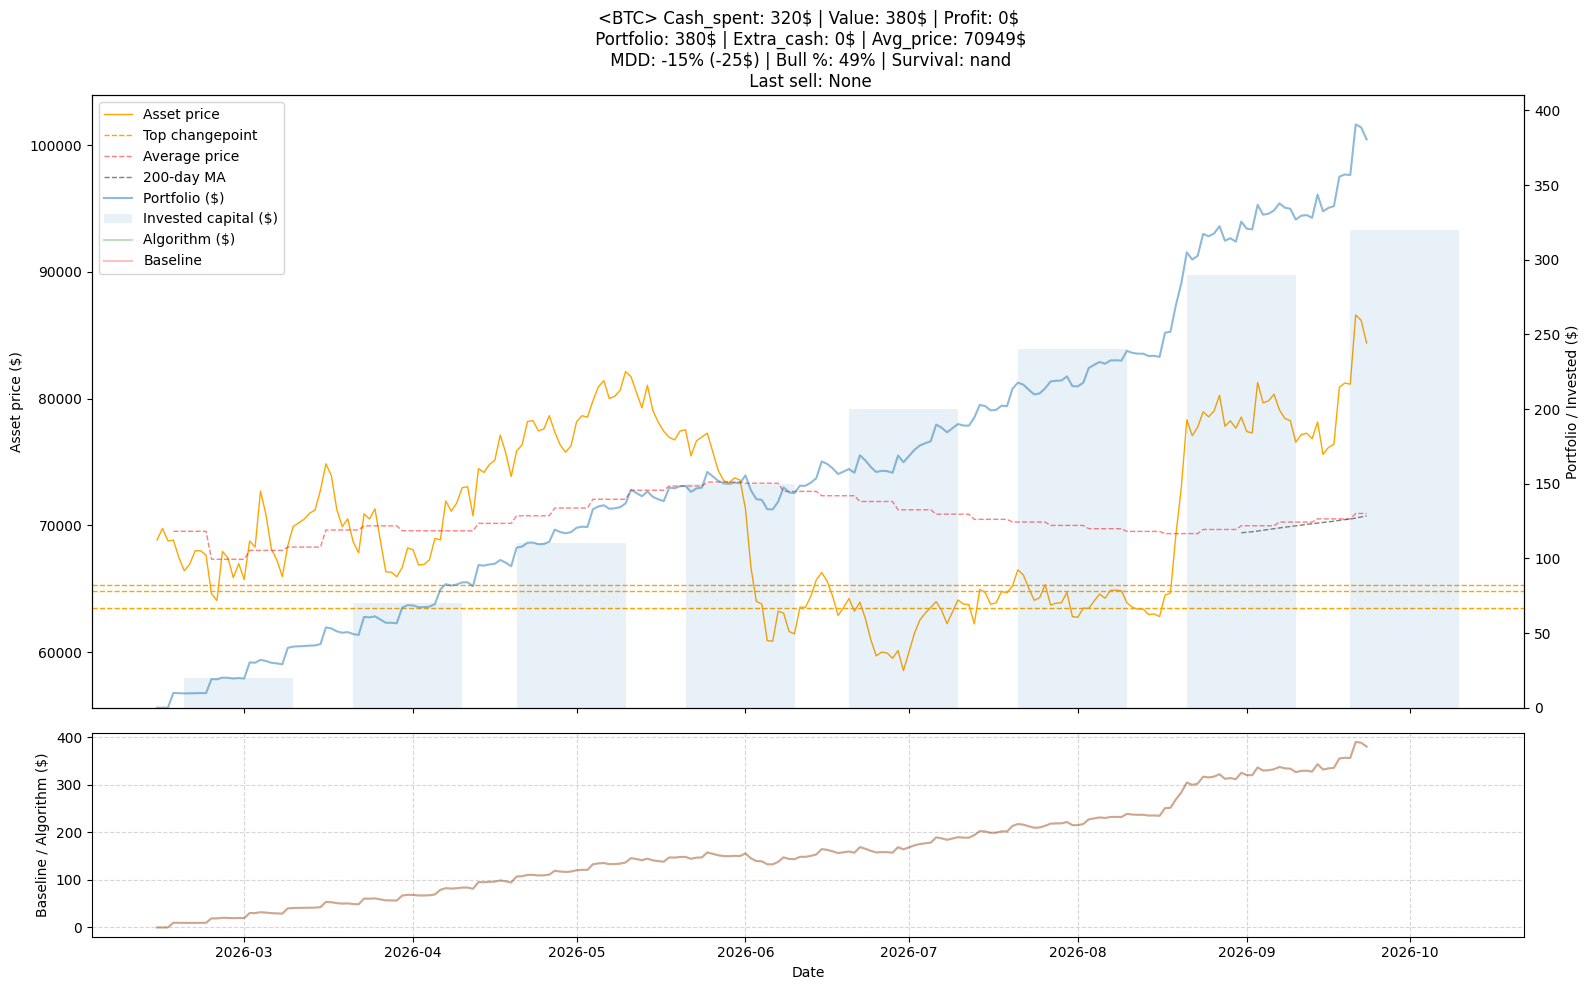

12:50:43 - cmdstanpy - INFO - Chain [1] start processing
12:50:44 - cmdstanpy - INFO - Chain [1] done processing


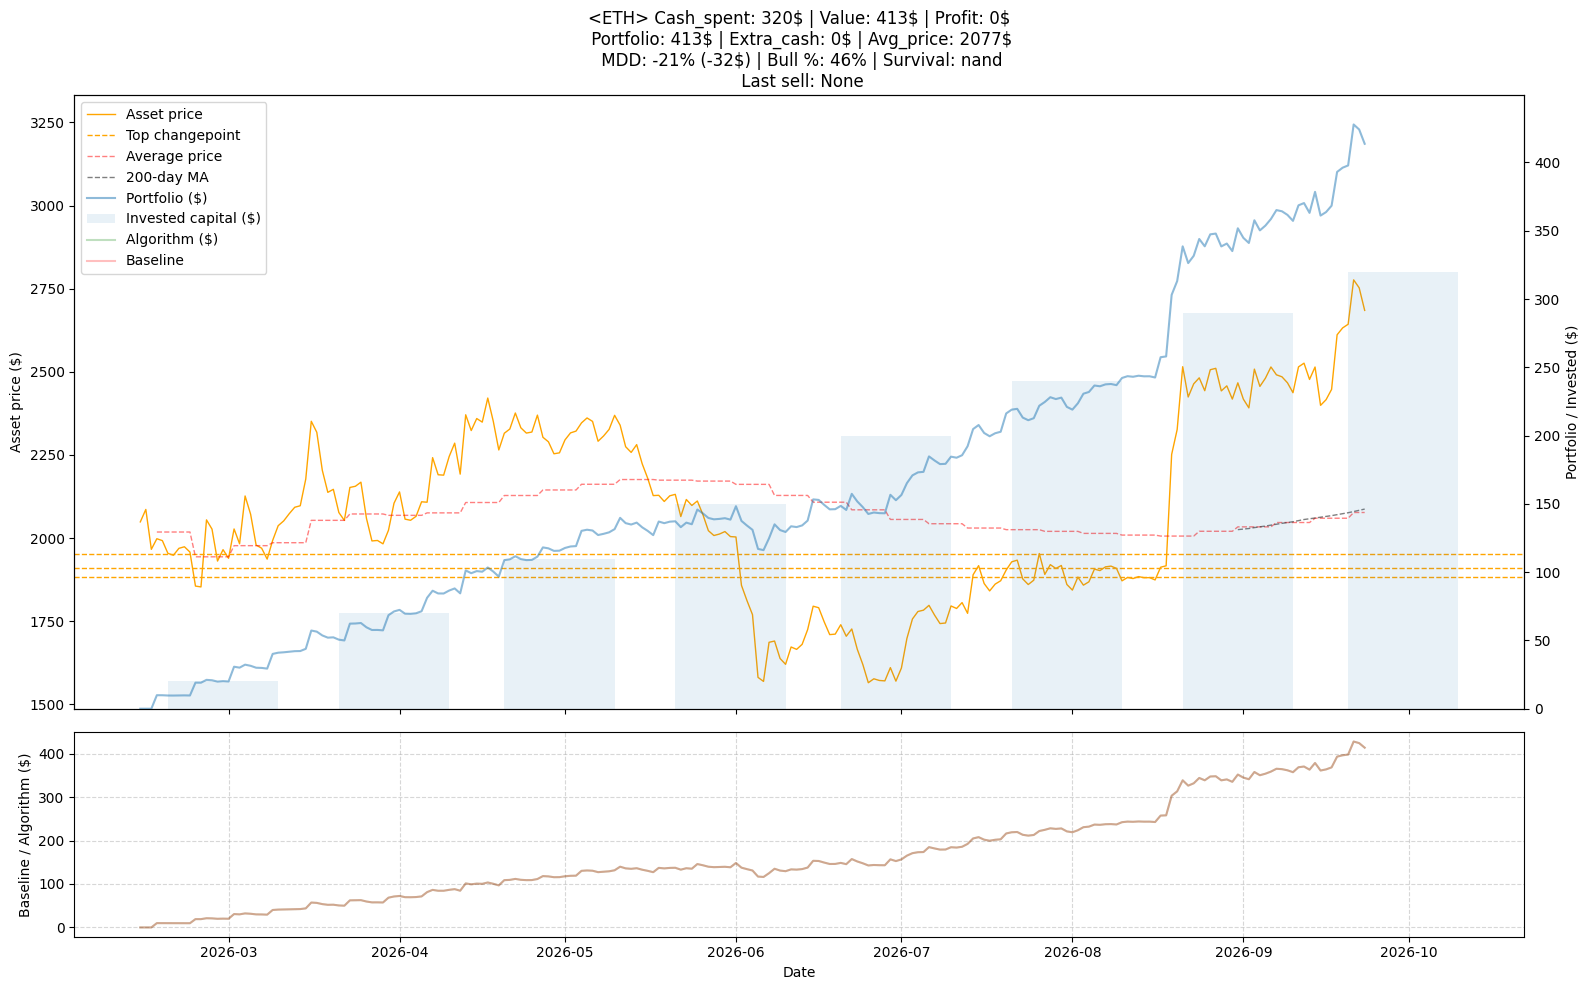

12:50:44 - cmdstanpy - INFO - Chain [1] start processing
12:50:44 - cmdstanpy - INFO - Chain [1] done processing


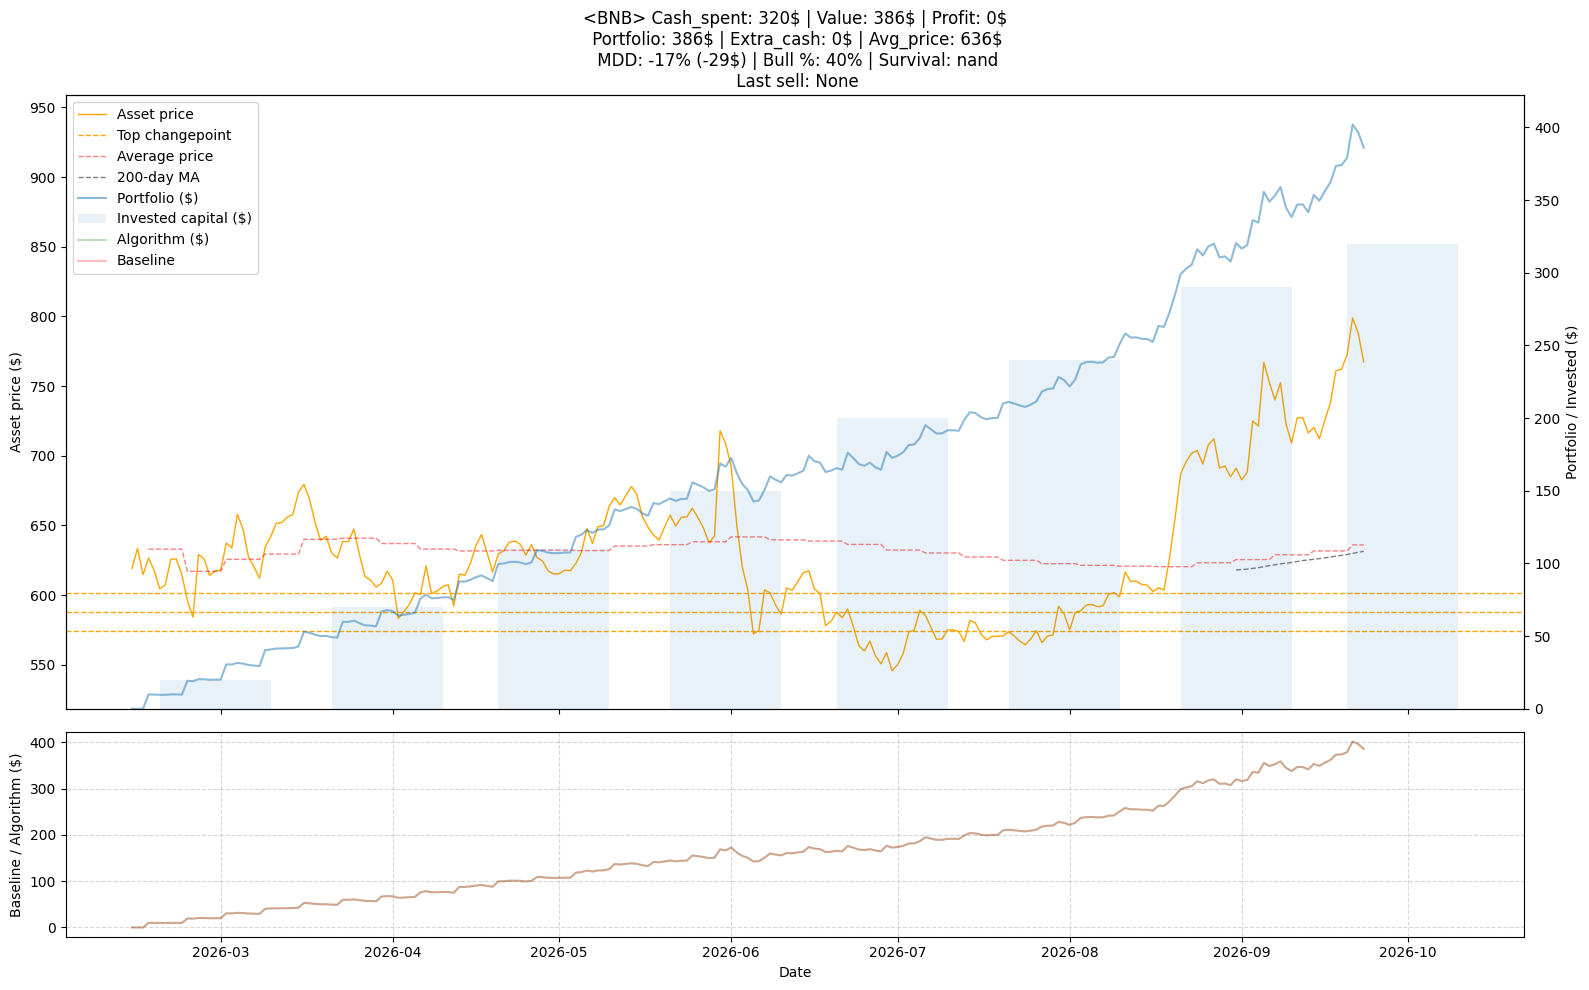

12:50:44 - cmdstanpy - INFO - Chain [1] start processing
12:50:44 - cmdstanpy - INFO - Chain [1] done processing


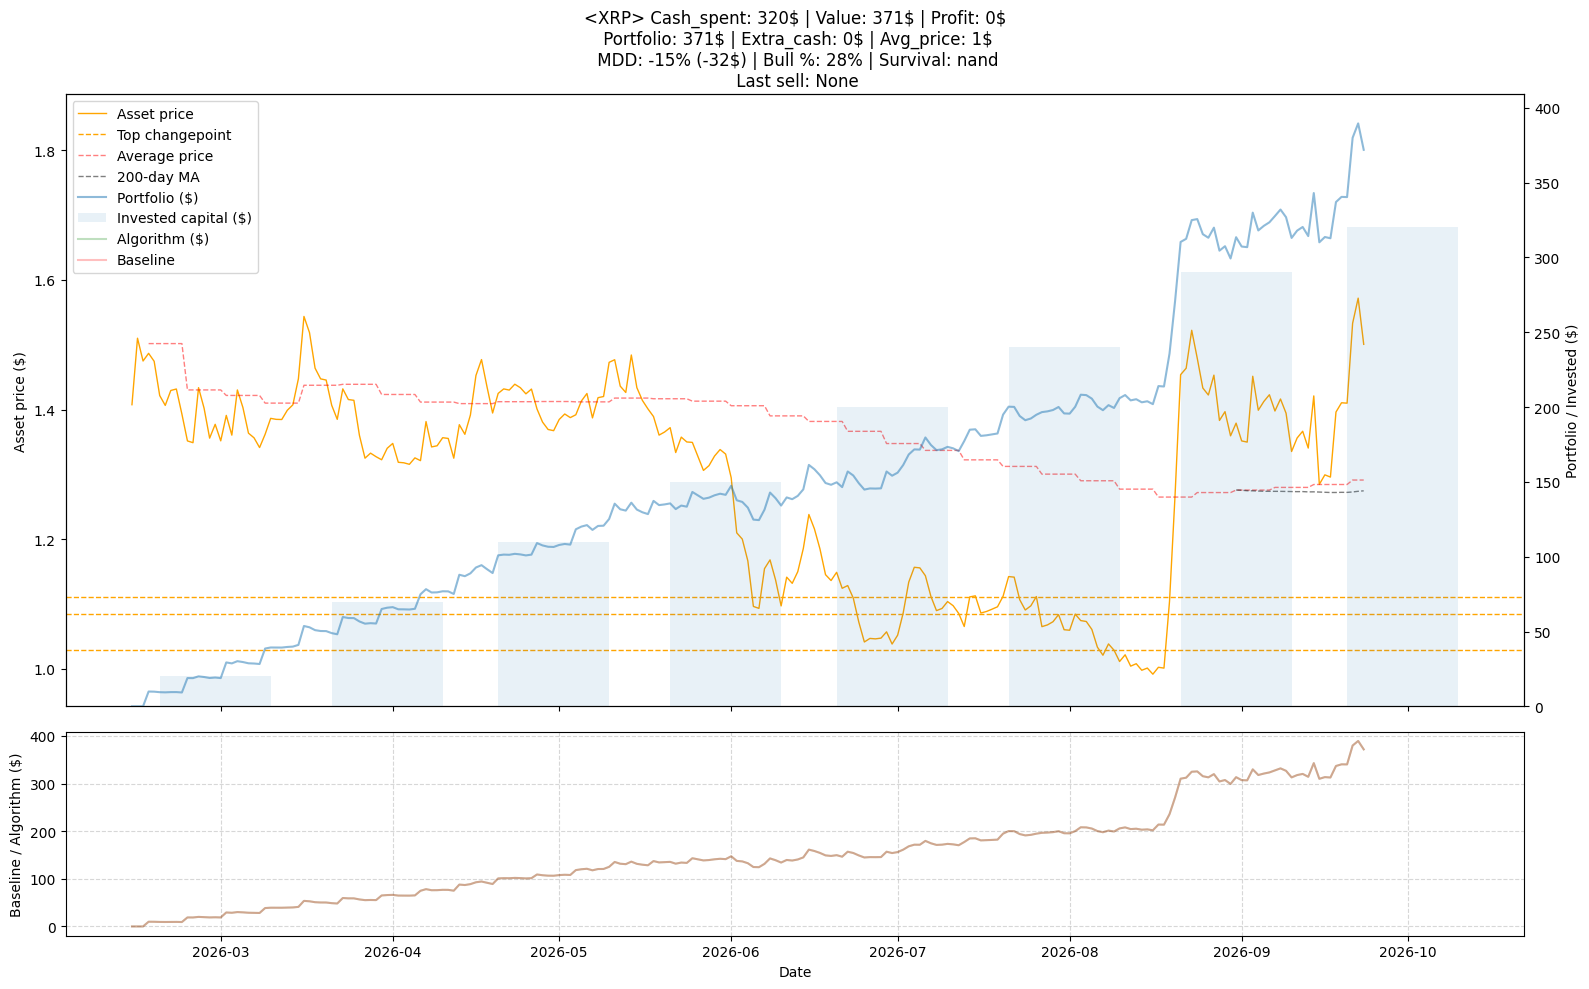

12:50:44 - cmdstanpy - INFO - Chain [1] start processing
12:50:44 - cmdstanpy - INFO - Chain [1] done processing


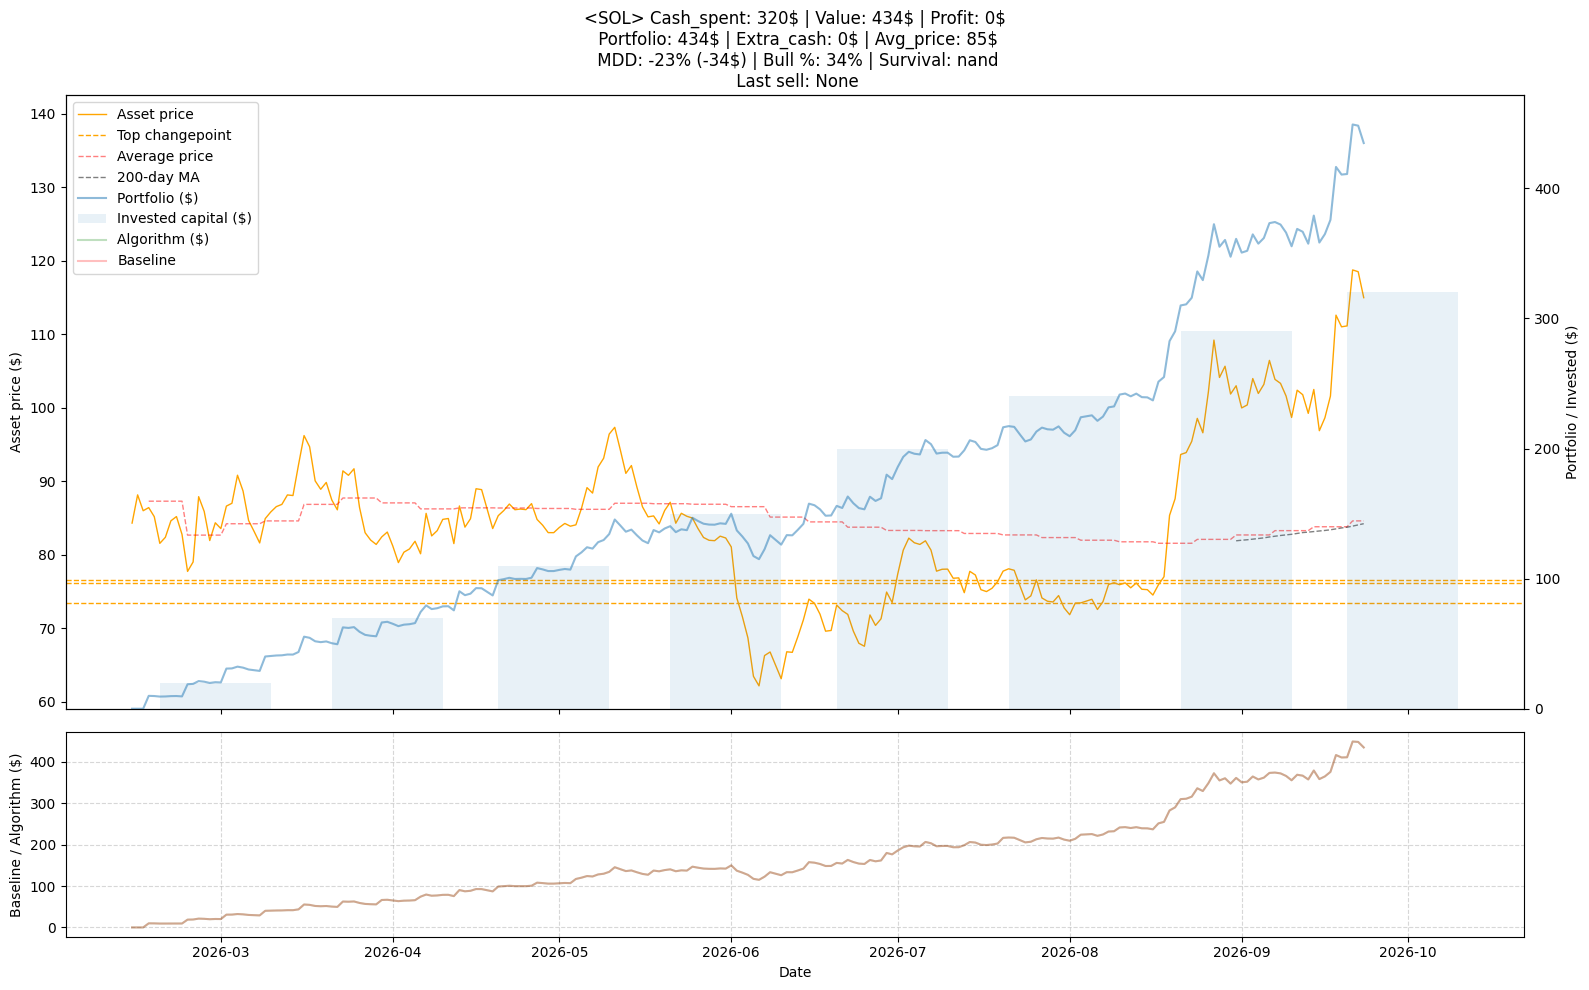

12:50:45 - cmdstanpy - INFO - Chain [1] start processing
12:50:45 - cmdstanpy - INFO - Chain [1] done processing


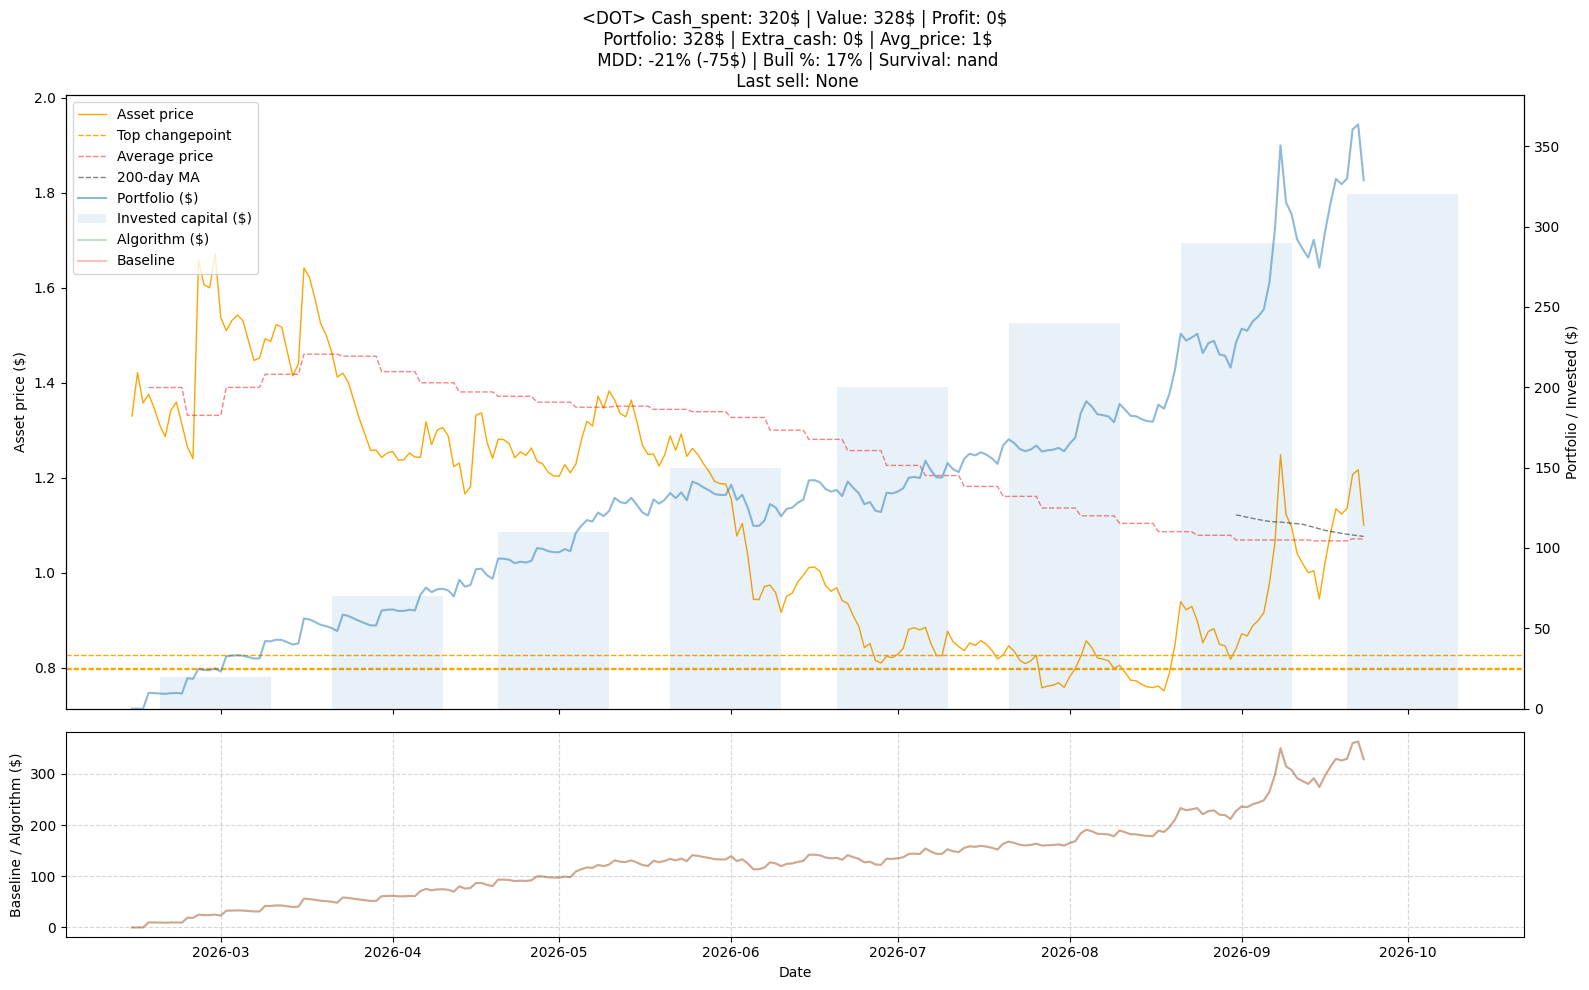

12:50:45 - cmdstanpy - INFO - Chain [1] start processing
12:50:45 - cmdstanpy - INFO - Chain [1] done processing


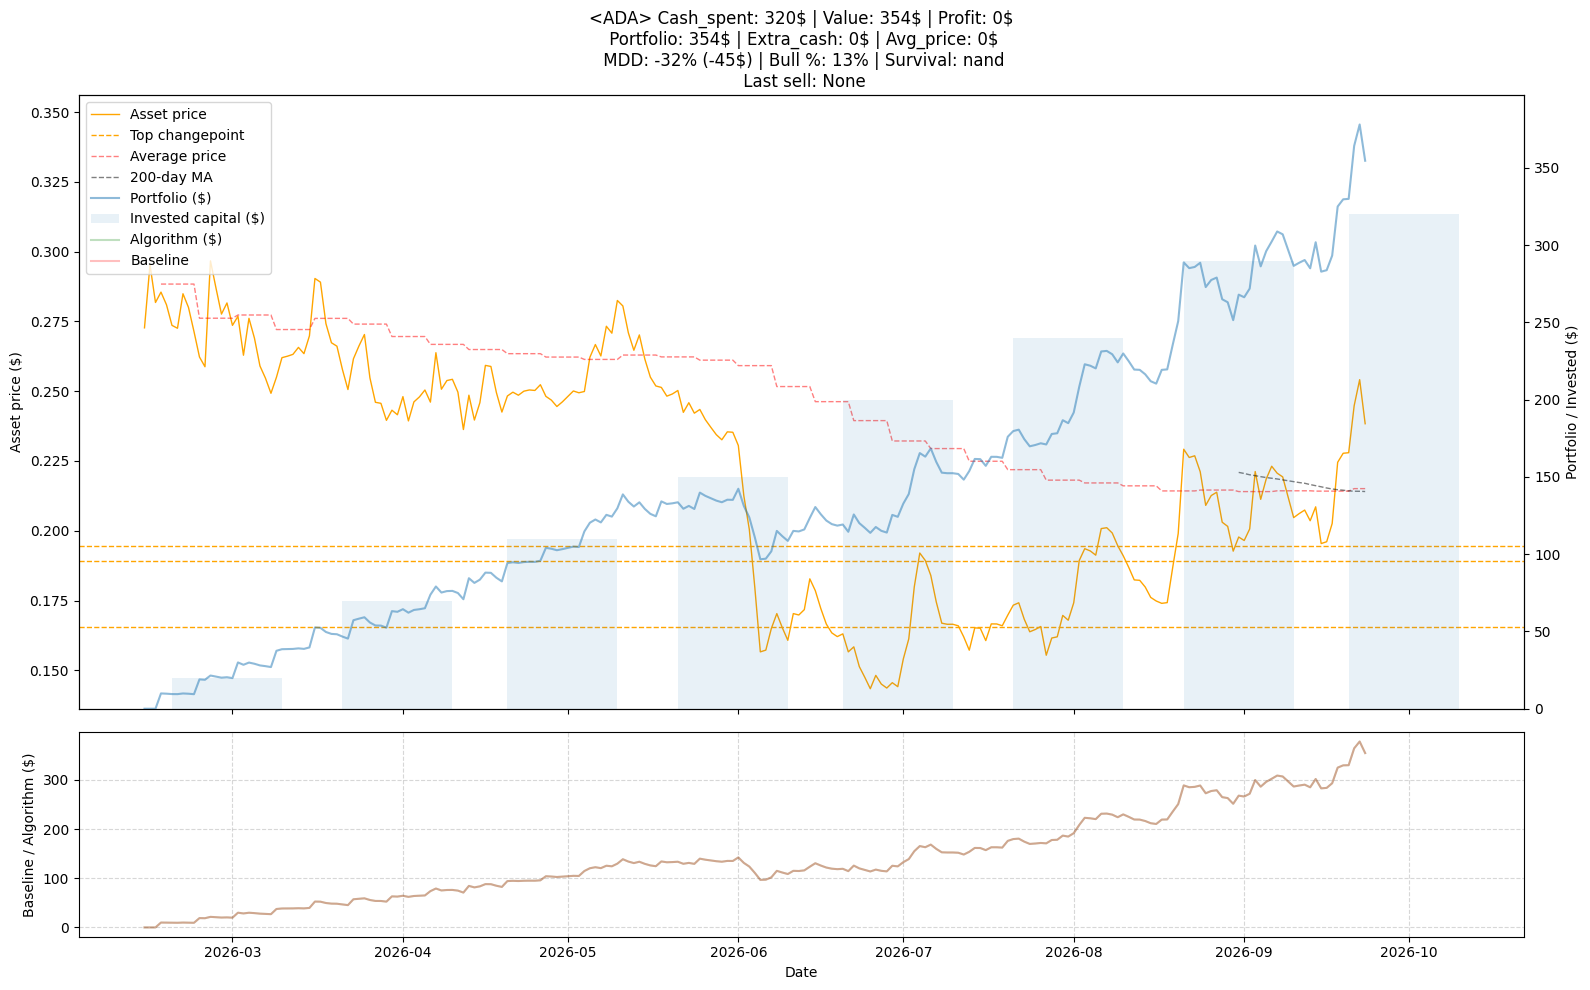

12:50:45 - cmdstanpy - INFO - Chain [1] start processing
12:50:45 - cmdstanpy - INFO - Chain [1] done processing


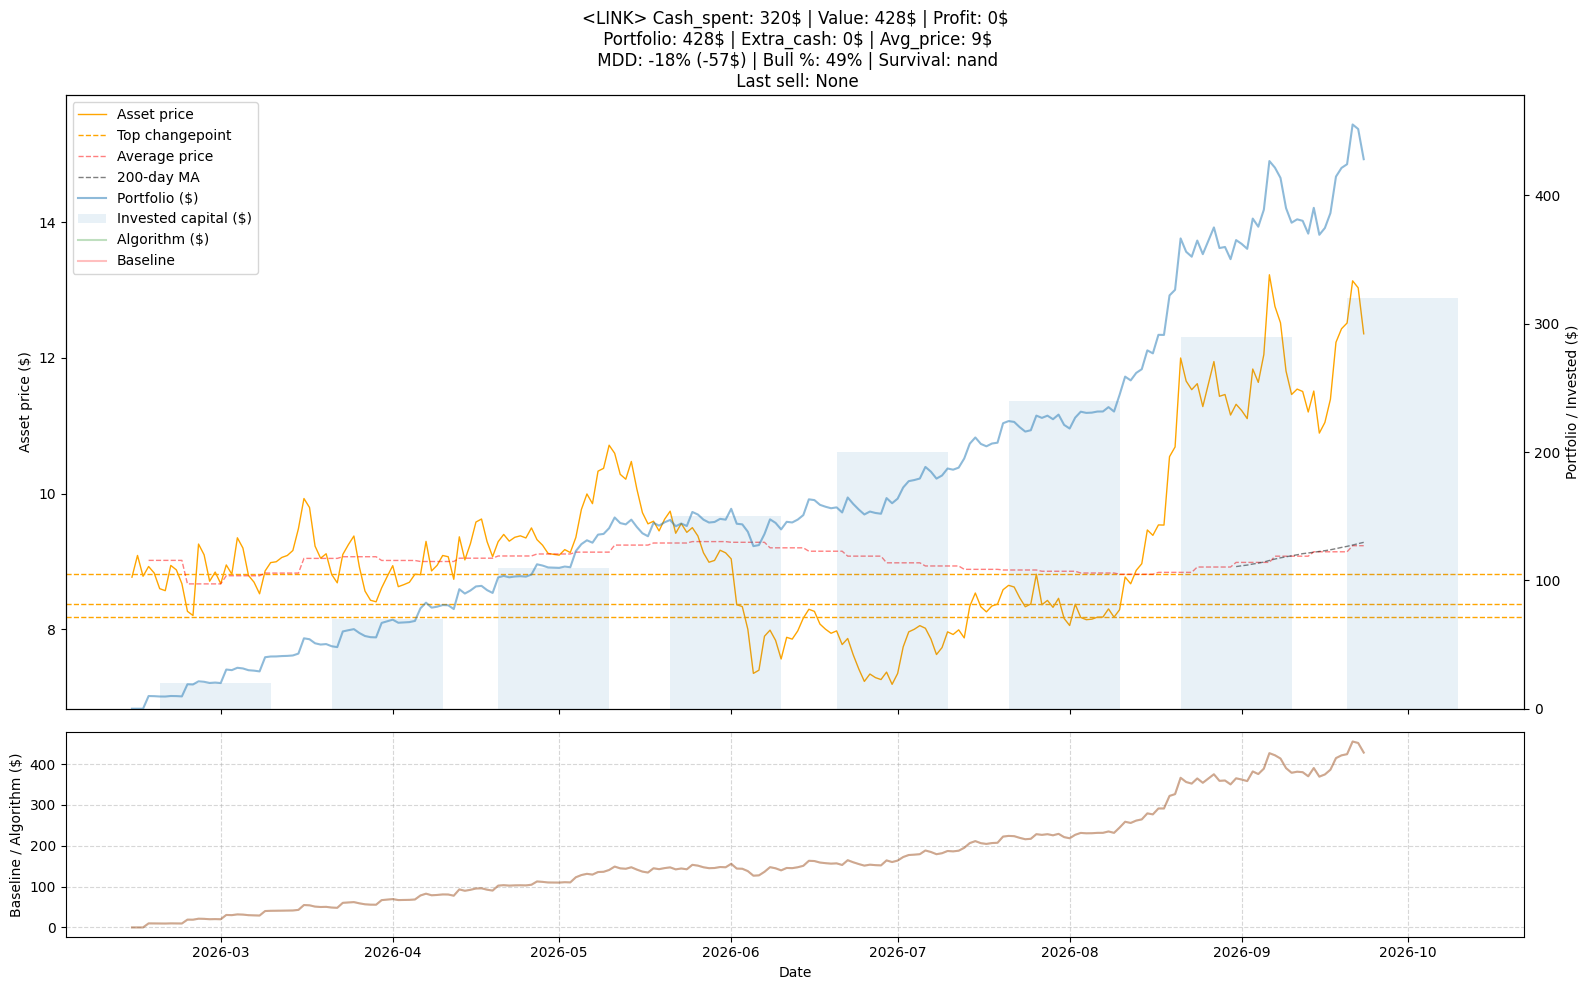

12:50:45 - cmdstanpy - INFO - Chain [1] start processing
12:50:45 - cmdstanpy - INFO - Chain [1] done processing


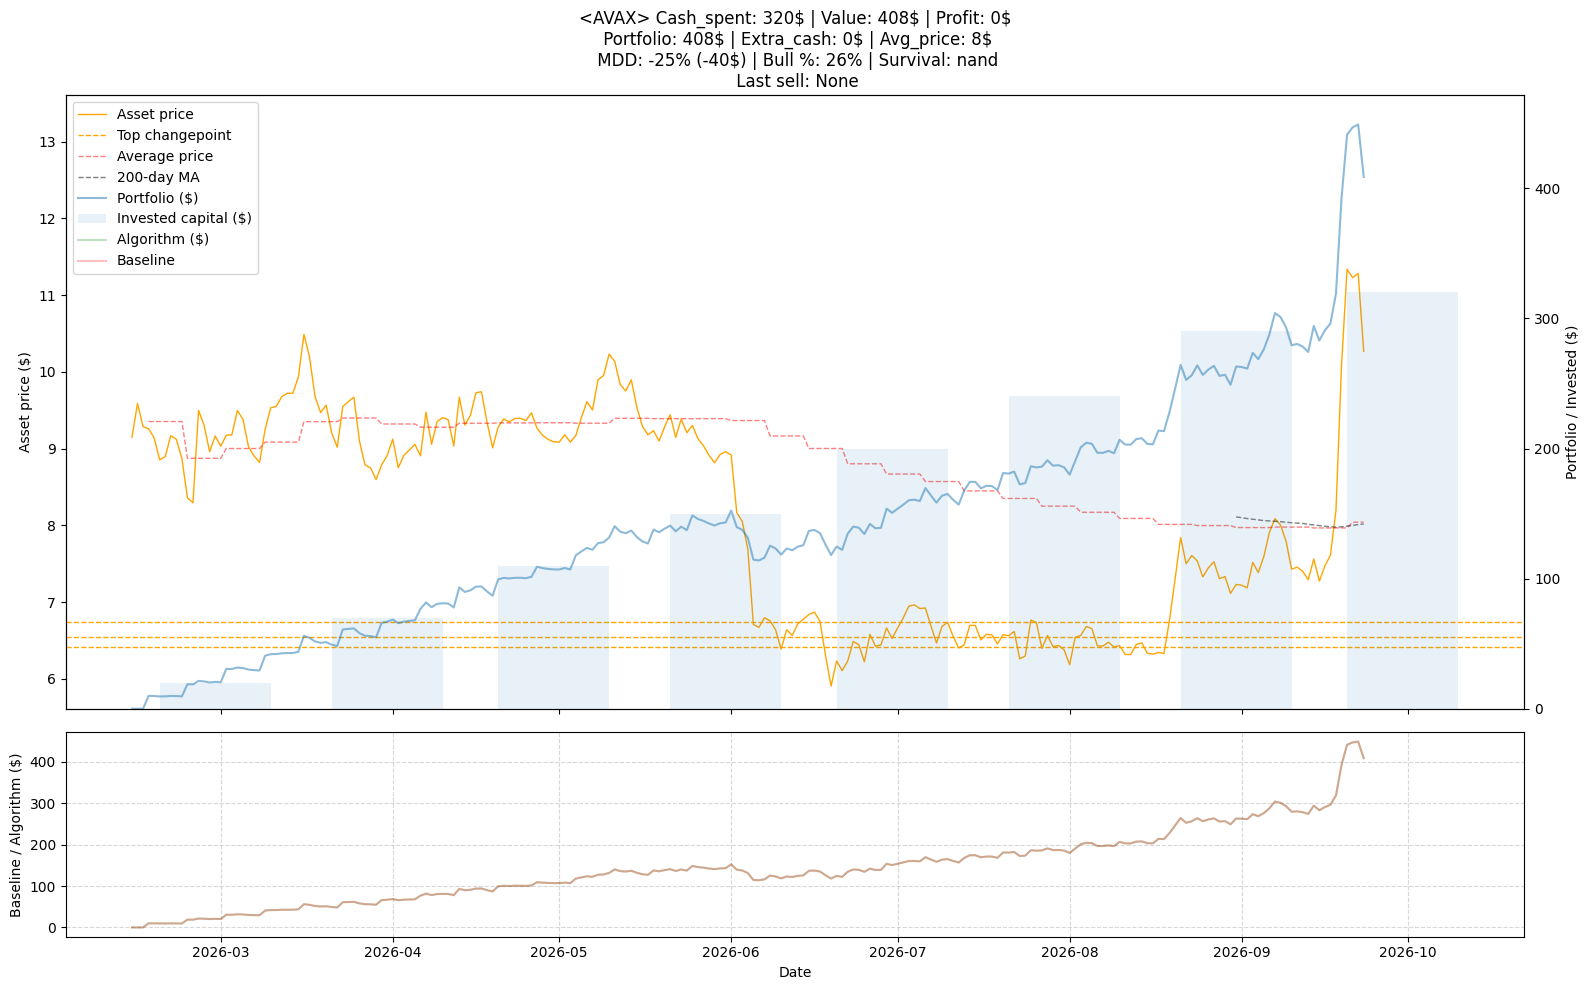

Total invested: $2880.00
Total profit: $0.00
Total return: $0.00
Total value: $3502.00


In [6]:
visualaise_strategy(df_crypto, crypto_strategy)

12:50:46 - cmdstanpy - INFO - Chain [1] start processing
12:50:46 - cmdstanpy - INFO - Chain [1] done processing


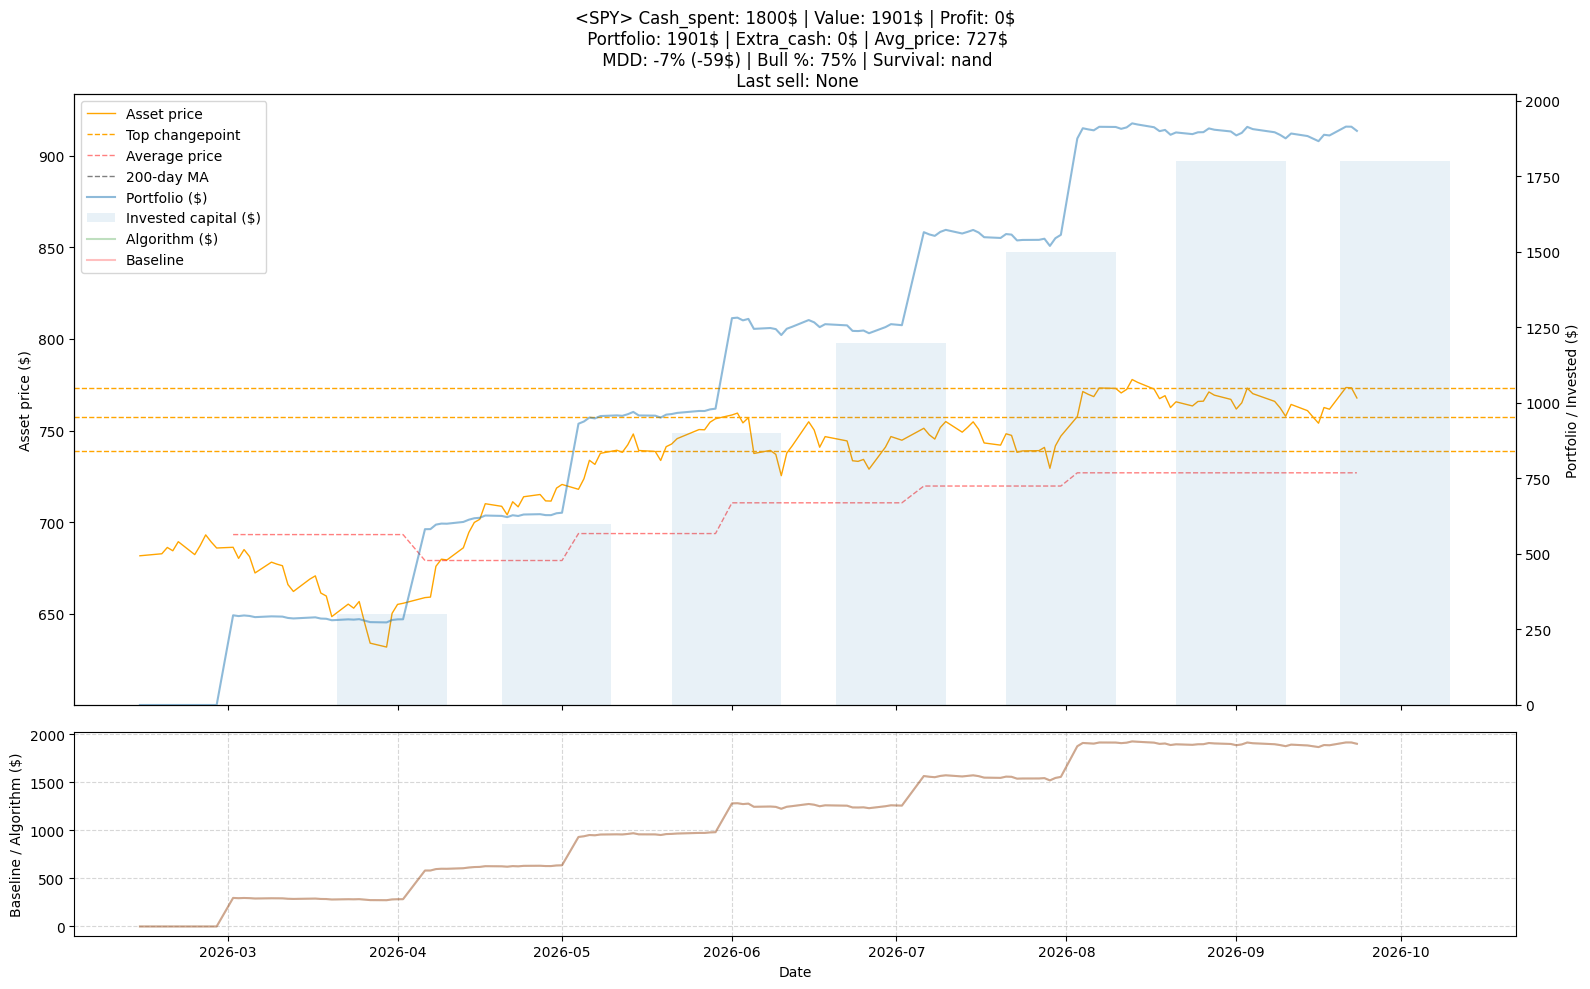

Total invested: $1800.00
Total profit: $0.00
Total return: $0.00
Total value: $1901.00


In [7]:
visualaise_strategy(df_stocks, stocks_strategy)